In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

# 1. ANÁLISIS EXPLORATORIO

Información básica del dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   expense_ratio        3000 non-null   float64
 1   debt_ratio           3000 non-null   float64
 2   savings_ratio        3000 non-null   float64
 3   discretionary_ratio  3000 non-null   float64
dtypes: float64(4)
memory usage: 93.9 KB
None

Estadísticas descriptivas
       expense_ratio   debt_ratio  savings_ratio  discretionary_ratio
count    3000.000000  3000.000000    3000.000000          3000.000000
mean        0.814007     0.137757       0.256901             0.135333
std         0.369109     0.076492       0.208377             0.072994
min         0.034643     0.000000       0.000000             0.000000
25%         0.583216     0.089948       0.043199             0.087294
50%         0.749035     0.125147       0.250965             0.125429


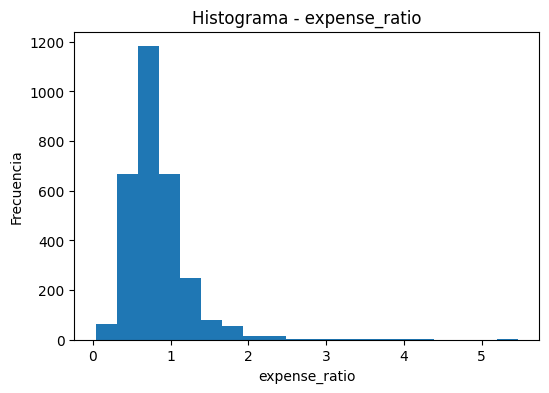

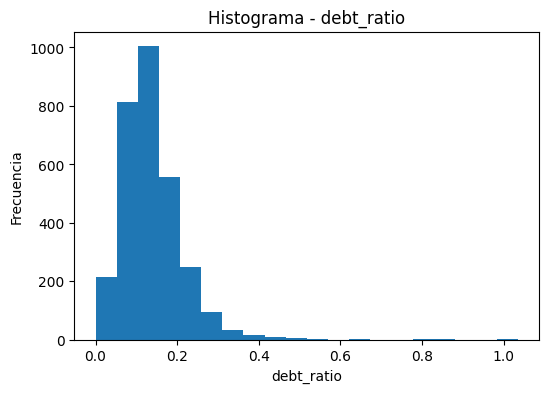

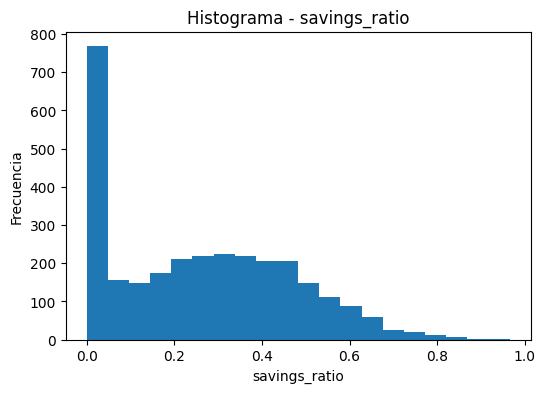

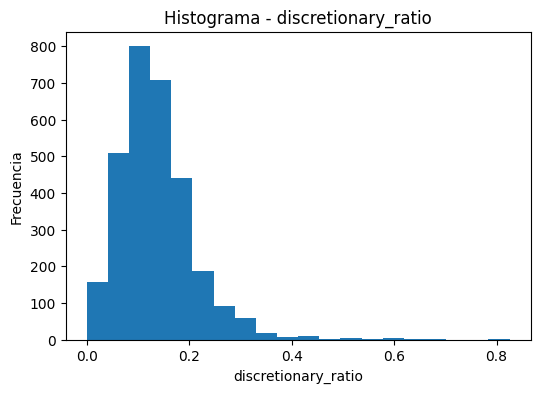

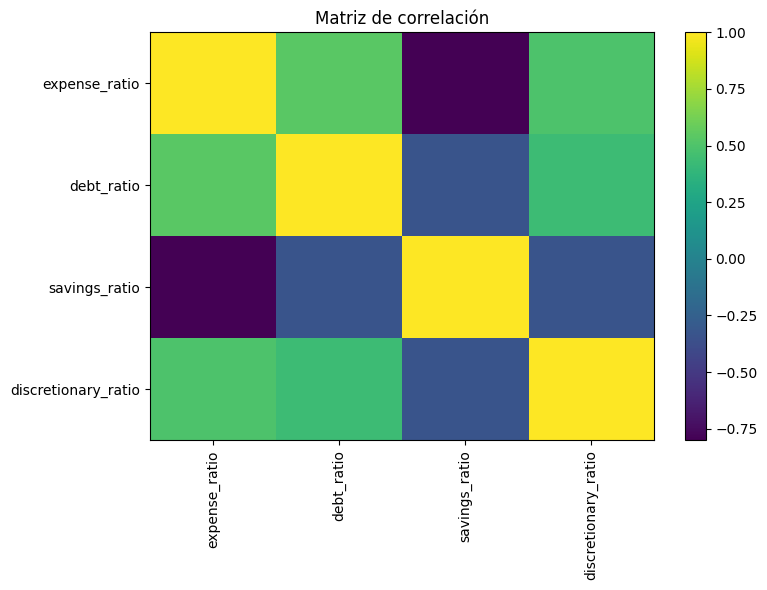


Valores correlación:
                     expense_ratio  debt_ratio  savings_ratio  \
expense_ratio             1.000000    0.536983      -0.801460   
debt_ratio                0.536983    1.000000      -0.330749   
savings_ratio            -0.801460   -0.330749       1.000000   
discretionary_ratio       0.497434    0.432661      -0.332323   

                     discretionary_ratio  
expense_ratio                   0.497434  
debt_ratio                      0.432661  
savings_ratio                  -0.332323  
discretionary_ratio             1.000000  


In [60]:

# Cargar dataset

df = pd.read_csv('/personal_finance_tracker_dataset.csv')

# Variables

features = [
    'monthly_income',
    'monthly_expense_total',
    'discretionary_spending',
    'essential_spending',
    'loan_payment',
    'actual_savings'
]

df['expense_ratio'] = (
    df['monthly_expense_total']
    /
    df['monthly_income']
)

df['debt_ratio'] = (
    df['loan_payment']
    /
    df['monthly_income']
)

df['savings_ratio'] = (
    df['actual_savings']
    /
    df['monthly_income']
)

df['discretionary_ratio'] = (
    df['discretionary_spending']
    /
    df['monthly_income']
)

features = [

    'expense_ratio',
    'debt_ratio',
    'savings_ratio',
    'discretionary_ratio'
]

df = df[features]

print("Información básica del dataset")
print(df.info())

print("\nEstadísticas descriptivas")
print(df.describe())

print("\nValores faltantes")
print(df.isnull().sum())


# Histogramas

for col in features:

    plt.figure(figsize=(6,4))

    plt.hist(
        df[col],
        bins=20
    )

    plt.title(f'Histograma - {col}')
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

    plt.show()

# Matriz correlación

correlation = df[features].corr()

plt.figure(figsize=(8,6))

plt.imshow(
    correlation,
    aspect='auto'
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Matriz de correlación")

plt.tight_layout()

plt.show()

print("\nValores correlación:")
print(correlation)


# 2. Preparación datos

In [61]:
X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 3. Evaluación del número óptimo de clusters


Calculando método del codo


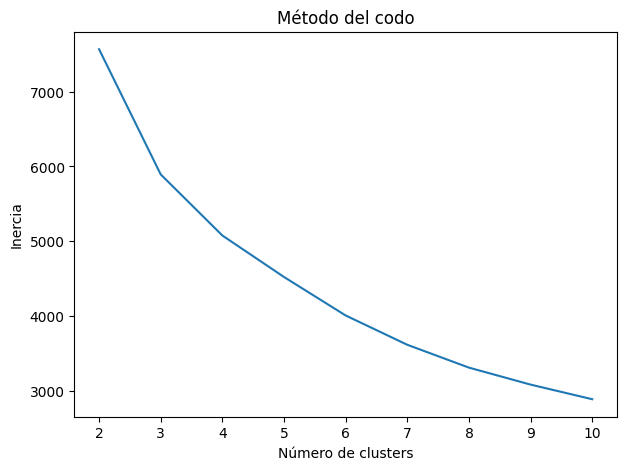


Buscando mejor K
K=2  Score=0.3713
K=3  Score=0.3234
K=4  Score=0.2639
K=5  Score=0.2302
K=6  Score=0.2465
K=7  Score=0.2428
K=8  Score=0.2412
K=9  Score=0.2434
K=10  Score=0.2304
Mejor K: 3
Score: 0.3234


In [57]:
# Metodo del codo

print("\nCalculando método del codo")

inertia = []

K_range = range(2,11)

for k in K_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(7,5))

plt.plot(
    K_range,
    inertia
)

plt.xlabel("Número de clusters")
plt.ylabel("Inercia")

plt.title("Método del codo")

plt.show()

# Silhouette Score

print("\nBuscando mejor K")

best_score = -1
best_k = 0

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f"K={k}  Score={score:.4f}")

    # if score > best_score:
    if k == 3:

        best_score = score
        best_k = k

print(f"Mejor K: {best_k}")
print(f"Score: {best_score:.4f}")

# 4. Modelado y entrenamiento con Kmeans

In [62]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters


# 5. Evaluación e interpretación


Resumen clusters:
         expense_ratio  debt_ratio  savings_ratio  discretionary_ratio
Cluster                                                               
0             0.566228    0.111746       0.433772             0.108785
1             0.958982    0.140920       0.095984             0.140762
2             1.573266    0.280066       0.013133             0.269150

Cantidad usuarios por cluster
Cluster
0    1489
1    1267
2     244
Name: count, dtype: int64


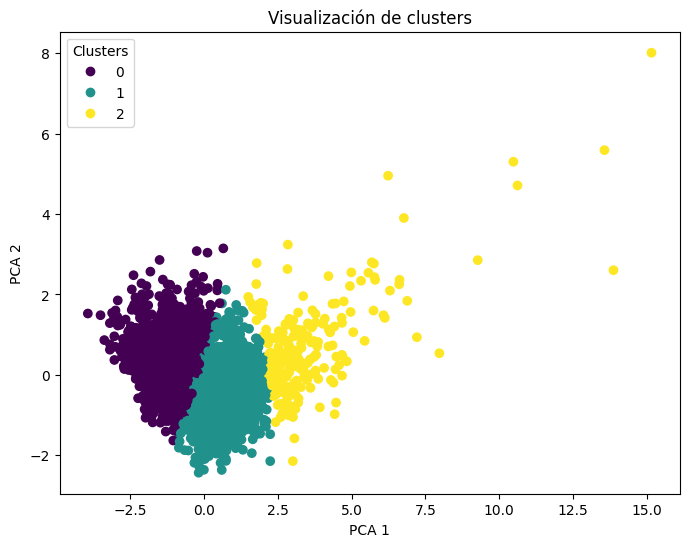

In [63]:
# Análisis de cluster

print("\nResumen clusters:")

cluster_summary = (
    df
    .groupby("Cluster")
    .mean()
)

print(cluster_summary)

print("\nCantidad usuarios por cluster")

print(
    df["Cluster"].value_counts()
)


# Visualización cluster PCA 2D

pca = PCA(
    n_components=2
)

components = pca.fit_transform(
    X_scaled
)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    components[:,0],
    components[:,1],
    c=clusters
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title(
    "Visualización de clusters"
)

plt.legend(
    *scatter.legend_elements(),
    title="Clusters"
)

plt.show()


# 6. Despliegue / Implementación

In [64]:
# Guardar modelos

joblib.dump(
    kmeans,
    'kmeans_model.pkl'
)

joblib.dump(
    scaler,
    'scaler.pkl'
)


['scaler.pkl']

# 7. Nueva predicción

In [65]:
# Cargar modelos

modelo_kmeans = joblib.load(
    'kmeans_model.pkl'
)

modelo_scaler = joblib.load(
    'scaler.pkl'
)

print("\nModelos cargados")

# Datos nueva predicción

income = 1600
expense = 400
discretionary = 1100
loan = 0
savings = 0

# Crear variables

expense_ratio = expense / income
debt_ratio = loan / income
savings_ratio = savings / income
discretionary_ratio = discretionary / income

# Crear df

nuevo_usuario = pd.DataFrame([{

    'expense_ratio': expense_ratio,
    'debt_ratio': debt_ratio,
    'savings_ratio': savings_ratio,
    'discretionary_ratio': discretionary_ratio

}])

print("\nDatos procesados:")

print(nuevo_usuario)

# Escalar

nuevo_scaled = modelo_scaler.transform(
    nuevo_usuario
)


# Predecir cluster

cluster = modelo_kmeans.predict(
    nuevo_scaled
)[0]

print("\n===== RESULTADOS =====")

print(
    f"Cluster: {cluster}"
)

# Perfiles

perfiles = {

    0:"Ahorrador disciplinado",
    1:"Usuario estable",
    2:"Riesgo financiero alto"

}

print(
    f"Perfil: {perfiles[cluster]}"
)

# Promedios cluster

cluster_data = cluster_summary.loc[
    cluster
]

print("\nCaracterísticas promedio:")

print(cluster_data)


Modelos cargados

Datos procesados:
   expense_ratio  debt_ratio  savings_ratio  discretionary_ratio
0           0.25         0.0            0.0               0.6875

===== RESULTADOS =====
Cluster: 2
Perfil: Riesgo financiero alto

Características promedio:
expense_ratio          1.573266
debt_ratio             0.280066
savings_ratio          0.013133
discretionary_ratio    0.269150
Name: 2, dtype: float64
